# laya + Thai distillation (OpenThai-SystemOne teacher) on Kaggle 2xT4

Copy of [batprem/fine-tune-laya-rlcd-on-your-own-typed-decisions](https://www.kaggle.com/code/batprem/fine-tune-laya-rlcd-on-your-own-typed-decisions) with `DATA_SOURCE="jsonl"` pointed at the dataset `chatre7/laya-thai-distill`: 16,116 Thai cases labelled by OpenThai-SystemOne (soft gold), plus an extra evaluation on 1,704 human-labelled cases and 848 teacher-labelled held-out cases. Pipeline and results: https://github.com/chatre7/laya (branch `thai`).

# Fine-Tuning Laya on Your Own Typed Decisions (Kaggle, T4)

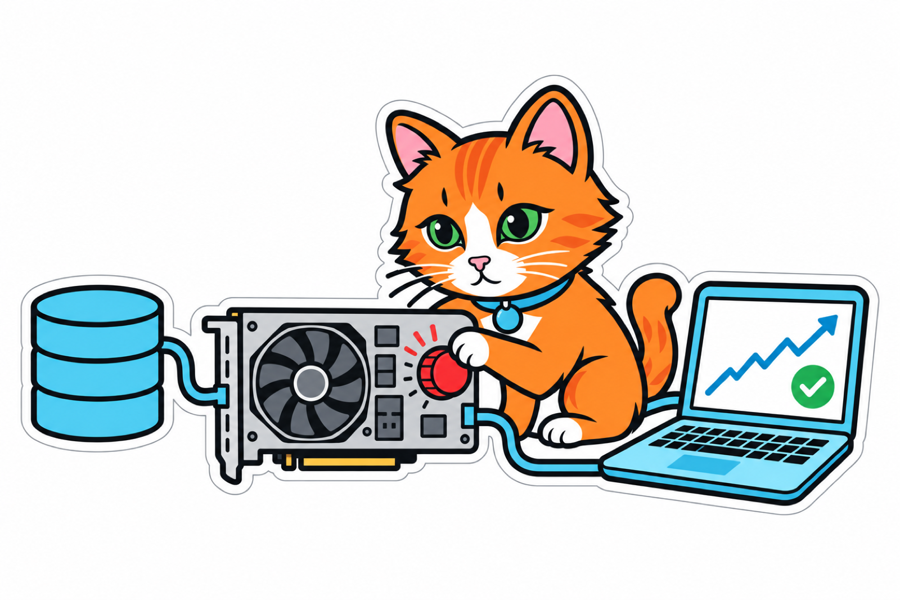

[![PyPI](https://img.shields.io/pypi/v/laya.svg)](https://pypi.org/project/laya/)
[![Model](https://img.shields.io/badge/%F0%9F%A4%97%20Model-convaiinnovations%2Flaya-blue)](https://huggingface.co/convaiinnovations/laya)
[![GitHub](https://img.shields.io/badge/GitHub-NandhaKishorM%2Flaya-black)](https://github.com/NandhaKishorM/laya)
[![License](https://img.shields.io/badge/License-Apache%202.0-green.svg)](https://opensource.org/licenses/Apache-2.0)

**Laya** is a *non-autoregressive System 1 decision model*. You give it a **state** (an email, a ticket, a JSON record) plus a set of **typed questions**, and it answers all of them in **one forward pass (~33 ms on a T4)** with calibrated probabilities. It never generates text, so there is nothing to parse and nothing to hallucinate.

Three question types:

| Type | Answer | Example |
|---|---|---|
| `choice` | one of N labels + full distribution | *Which department handles this?* |
| `score` | ordered rubric level + expected score | *How urgent is this? (0 = not urgent … 2 = critical)* |
| `noul` | yes / no probability | *Is the customer asking for a refund?* |

**Why fine-tune?** The authors are explicit: the base checkpoints score near chance zero-shot on a new workflow. Fine-tuning is where the capability comes from (on the typed-decisions benchmark: 0.36 zero-shot → 0.77 fine-tuned). Laya is a *fast base to specialise*, not a zero-shot engine.

### What this notebook does

1. Installs `laya` and picks a base checkpoint (English or multilingual).
2. Gets a training set of typed decisions, either **built in this notebook** (demo Thai/English generator, your JSONL, or `LocalLLaMA/typed-decisions`) or **imported** from the companion *Build a Laya Typed-Decisions Dataset* notebook. `LAYA_DATA_MODE` switches between the two.
3. Trains with **RLCD** (Reinforcement Learning for Calibrated Decisions): GRPO-style policy gradient with strictly proper scoring rules as reward, plus soft cross-entropy. Works on 1 or 2 GPUs.
4. Fits post-training **calibration temperatures**.
5. Evaluates **zero-shot vs fine-tuned** on a held-out split (accuracy, Brier, ECE).
6. Runs inference with `laya.Agent` and optionally pushes to the Hugging Face Hub.

### ⚠️ Kaggle notebook settings (right sidebar → *Notebook options*)

* **Accelerator:** `GPU T4 x2` (recommended) or `GPU T4`. The training script adapts to however many GPUs are visible.
* **Internet:** `On` (needed to download the checkpoint and dataset).
* **Persistence:** outputs go to `/kaggle/working/laya_finetuned`.
* **Import mode only:** add the dataset-builder notebook (or a Kaggle Dataset made from its output) under **+ Add Input**.

## 1. Environment and GPU check

In [ ]:
!nvidia-smi
import os, torch

N_GPU = torch.cuda.device_count()
print(f"CUDA available: {torch.cuda.is_available()} | visible GPUs: {N_GPU}")
for i in range(N_GPU):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} ({p.total_memory / 1e9:.1f} GB)")
assert N_GPU >= 1, "No GPU detected. Set Accelerator -> GPU T4 x2 (or GPU T4) in Notebook options."

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

## 2. Install dependencies

In [ ]:
!pip install -q -U laya "datasets>=3.0.0" safetensors huggingface_hub accelerate tabulate
import laya, transformers, torch
print("laya         :", laya.__version__)
print("transformers :", transformers.__version__)
print("torch        :", torch.__version__)

## 3. Configuration

### Data mode (environment variable)

| `LAYA_DATA_MODE` | behaviour |
|---|---|
| `build` (default) | build the dataset inside this notebook from `DATA_SOURCE` using the same code as the builder notebook |
| `import` | load a prebuilt dataset. Directory = `LAYA_DATA_DIR` if set, otherwise the first folder under `/kaggle/input` containing `dataset_meta.json` + items |

Set it in the cell below, e.g. `%env LAYA_DATA_MODE=import`, or leave it unset to build. In import mode `BASE_MODEL` / `SUBFOLDER` are taken from the dataset's `dataset_meta.json`, because the tokenised items are checkpoint-specific.

### Base checkpoint

| `SUBFOLDER` | Encoder | Params | Context | Use for |
|---|---|---|---|---|
| `None` | ModernBERT-large | 421M | 512 | English only |
| `"multilingual"` | mmBERT-base | 322M | 1024 | 100+ languages (incl. Thai), ~2× faster |

In [ ]:
# %env LAYA_DATA_MODE=import
# %env LAYA_DATA_DIR=/kaggle/input/build-laya-typed-decisions-dataset/laya_dataset

DATA_MODE = os.environ.get("LAYA_DATA_MODE", "build").lower()
DATA_DIR  = os.environ.get("LAYA_DATA_DIR") or None
assert DATA_MODE in ("build", "import"), f"LAYA_DATA_MODE must be 'build' or 'import', got {DATA_MODE!r}"

BASE_MODEL  = "convaiinnovations/laya"
SUBFOLDER   = "multilingual"        # None -> English ModernBERT-large checkpoint

DATA_SOURCE = "jsonl"               # Thai distillation set labelled by OpenThai-SystemOne
import glob as _glob
_found = sorted(_glob.glob("/kaggle/input/**/train.jsonl", recursive=True))
print("input tree:", sorted(_glob.glob("/kaggle/input/*/*"))[:20])
assert _found, "dataset chatre7/laya-thai-distill is not attached (Add Input) or has no train.jsonl"
JSONL_PATH  = _found[0]
DATA_INPUT_DIR = os.path.dirname(JSONL_PATH)
print("JSONL_PATH:", JSONL_PATH)
VAL_FRAC    = 0.05
SEED        = 42

WORK_DIR    = "/kaggle/working"
OUTPUT_DIR  = f"{WORK_DIR}/laya_finetuned"

# Training hyper-parameters (per GPU)
EPOCHS        = 2
MICRO_BATCH   = 8       # sequences per forward pass per GPU
GRAD_ACCUM    = 4       # effective batch = MICRO_BATCH * GRAD_ACCUM * n_gpu
GROUP_SIZE    = 4       # GRPO samples per sequence
LR_ENCODER    = 2.5e-5
LR_HEAD       = 1.0e-4
SIGMA_START   = 0.4     # exploration noise on logits, annealed linearly ...
SIGMA_END     = 0.1     # ... to this value on the last epoch
CE_WEIGHT     = 1.0     # weight of the soft cross-entropy term next to the RL term
print("DATA_MODE:", DATA_MODE)

### 3.1 Shared data module

Identical to the one in the dataset-builder notebook. Needed in both modes (evaluation uses `gold_to_target`).

In [ ]:
%%writefile laya_data.py

"""laya_data.py - shared dataset builder for the Laya notebooks.

Turns cases ({state, questions, gold}) into tokenised Laya training items and back.
Written by both the dataset notebook and the fine-tune notebook so they agree byte-for-byte.
"""
import json, os, random
import torch
from laya.common import build_sequence, render_options, QTYPES

LABEL_SMOOTH = 0.05

import random

DEMO_QUESTIONS = {
    "department": {
        "type": "choice",
        "instructions": "Which department should handle this ticket? / ตั๋วนี้ควรส่งให้แผนกไหน",
        "criteria": {
            "billing":   "invoices, duplicate charges, payments, refunds / ใบแจ้งหนี้ การเรียกเก็บเงินซ้ำ การชำระเงิน การคืนเงิน",
            "technical": "bugs, outages, errors, login problems, slow app / บั๊ก ระบบล่ม ข้อผิดพลาด เข้าสู่ระบบไม่ได้ แอปช้า",
            "sales":     "pricing, plan upgrades, quotes, new contracts / ราคา อัปเกรดแพ็กเกจ ใบเสนอราคา สัญญาใหม่",
            "other":     "everything else / เรื่องอื่น ๆ",
        },
    },
    "urgency": {
        "type": "score",
        "instructions": "How urgent is this ticket? / ตั๋วนี้เร่งด่วนแค่ไหน",
        "criteria": [
            "not urgent: general question, no deadline / ไม่เร่งด่วน สอบถามทั่วไป",
            "soon: customer is blocked or annoyed but no hard deadline / ควรตอบเร็ว ลูกค้าติดขัด",
            "critical: outage, data loss, legal or churn threat, deadline today / วิกฤต ระบบล่ม ขู่ยกเลิก ต้องแก้วันนี้",
        ],
    },
    "refund_requested": {
        "type": "noul",
        "instructions": "Is the customer explicitly asking for money back? / ลูกค้าขอเงินคืนอย่างชัดเจนหรือไม่",
    },
}

_T = {
    "billing": [
        ("Duplicate charge on invoice #{n}", "We were billed twice for {month}. Please refund the duplicate.", True),
        ("เรียกเก็บเงินซ้ำ ใบแจ้งหนี้ #{n}", "โดนหักเงินสองครั้งสำหรับเดือน{month} รบกวนคืนเงินส่วนที่เกินด้วยค่ะ", True),
        ("Invoice #{n} shows wrong VAT", "The VAT line looks wrong on this month's invoice, can you check?", False),
        ("ใบเสร็จ #{n} ยอดไม่ตรง", "ยอดในใบเสร็จไม่ตรงกับที่ตกลงไว้ ช่วยตรวจสอบให้หน่อยครับ", False),
        ("Cancel and refund", "I want to cancel my subscription and get this month's payment back.", True),
        ("ขอยกเลิกและคืนเงิน", "ต้องการยกเลิกบริการและขอเงินเดือนนี้คืน", True),
    ],
    "technical": [
        ("Cannot log in since this morning", "Login page returns error 500 for our whole team. We are completely blocked.", False),
        ("เข้าสู่ระบบไม่ได้ตั้งแต่เช้า", "หน้า login ขึ้น error 500 ทั้งทีมใช้งานไม่ได้เลย", False),
        ("Export is very slow", "CSV export of {n} rows takes 10 minutes. Not blocking but annoying.", False),
        ("ส่งออกไฟล์ช้ามาก", "export CSV {n} แถวใช้เวลาเกือบ 10 นาที ยังพอใช้ได้แต่ช้ามาก", False),
        ("Dashboard shows wrong numbers", "The revenue widget is off by a lot since the last update.", False),
        ("แดชบอร์ดแสดงตัวเลขผิด", "ตั้งแต่อัปเดตล่าสุด ตัวเลขรายได้ไม่ตรงเลยค่ะ", False),
    ],
    "sales": [
        ("Quote for {n} seats", "We are evaluating the Business plan for {n} users. Can you send pricing?", False),
        ("ขอใบเสนอราคา {n} ผู้ใช้", "กำลังพิจารณาแพ็กเกจ Business สำหรับ {n} คน ขอราคาหน่อยครับ", False),
        ("Upgrade to annual plan", "Is there a discount if we switch to annual billing?", False),
        ("อัปเกรดเป็นรายปี", "ถ้าเปลี่ยนเป็นจ่ายรายปีมีส่วนลดไหมคะ", False),
    ],
    "other": [
        ("Partnership inquiry", "We run a podcast and would love to feature your product.", False),
        ("สอบถามเรื่องความร่วมมือ", "เราทำพอดแคสต์ อยากเชิญมาแนะนำผลิตภัณฑ์", False),
        ("Where is your office?", "Just curious whether you have an office in Bangkok.", False),
        ("ที่อยู่บริษัท", "อยากทราบว่ามีสำนักงานที่กรุงเทพไหมครับ", False),
    ],
}
_URGENCY_TAIL = {
    0: ["", " No rush.", " ไม่รีบค่ะ", " Whenever you have time."],
    1: [" Please reply within a couple of days.", " รบกวนตอบภายในสองสามวันนะคะ", " This is slowing us down."],
    2: [" This must be fixed TODAY or we cancel.", " ถ้าไม่แก้วันนี้จะยกเลิกสัญญา", " Our launch is in 2 hours!", " ระบบล่มทั้งบริษัท ด่วนมาก"],
}

def _soft(keys, hot, conf):
    rest = (1.0 - conf) / max(1, len(keys) - 1)
    return {k: (conf if k == hot else rest) for k in keys}

def make_demo_case(rng, i):
    dept = rng.choices(["billing", "technical", "sales", "other"], weights=[4, 4, 2, 1])[0]
    subj, body, refund = rng.choice(_T[dept])
    subj = subj.format(n=rng.randint(1000, 9999), month=rng.choice(["March", "April", "มีนาคม", "เมษายน"]))
    body = body.format(n=rng.randint(50, 5000), month=rng.choice(["March", "April", "มีนาคม", "เมษายน"]))
    base_urg = {"billing": 1, "technical": 1, "sales": 0, "other": 0}[dept]
    urg = min(2, max(0, base_urg + rng.choice([-1, 0, 0, 0, 1])))
    body += rng.choice(_URGENCY_TAIL[urg])
    if rng.random() < 0.15:                      # explicit refund ask added to any ticket
        body += rng.choice([" I also expect a refund for the downtime.", " และขอเงินคืนสำหรับช่วงที่ใช้งานไม่ได้ด้วย"])
        refund = True
    state = {"from": f"user{i}@{rng.choice(['acme.co.th', 'example.com', 'siam-corp.com'])}",
             "plan": rng.choice(["Free", "Pro", "Business"]), "subject": subj, "body": body}
    dept_conf = rng.uniform(0.75, 0.97)
    gold = {
        "department": {"label": dept, "probabilities": _soft(list(DEMO_QUESTIONS["department"]["criteria"]), dept, dept_conf)},
        "urgency": {"label": urg, "probabilities": _soft(["0", "1", "2"], str(urg), rng.uniform(0.6, 0.9))},
        "refund_requested": {"label": refund, "probabilities": _soft(["false", "true"], "true" if refund else "false", rng.uniform(0.8, 0.98))},
    }
    return {"id": f"demo-{i:04d}", "state": state, "questions": DEMO_QUESTIONS, "gold": gold}

def build_demo_cases(n=800, seed=42):
    rng = random.Random(seed)
    return [make_demo_case(rng, i) for i in range(n)]
def load_cases(source, jsonl_path=None):
    if source == "demo":
        return build_demo_cases()
    if source == "jsonl":
        with open(jsonl_path) as f:
            return [json.loads(l) for l in f if l.strip()]
    if source == "typed-decisions":
        from datasets import load_dataset
        ds = load_dataset("LocalLLaMA/typed-decisions", "all", split="train")
        return [{"id": r["id"], "state": json.loads(r["state"]), "questions": json.loads(r["questions"]),
                 "gold": json.loads(r["gold"])} for r in ds]
    raise ValueError(f"unknown DATA_SOURCE {source!r}")


def split_cases(cases, val_frac=0.1, seed=42):
    cases = list(cases)
    random.Random(seed).shuffle(cases)
    n_val = max(20, int(val_frac * len(cases)))
    return cases[n_val:], cases[:n_val]


def gold_to_target(qdef, g):
    t, crit = qdef["type"], qdef.get("criteria", {})
    if t == "choice":
        keys = list(crit.keys())
    elif t == "score":
        keys = [str(i) for i in range(len(crit) if isinstance(crit, list) else 4)]
    else:
        keys = ["false", "true"]
    probs = g.get("probabilities")
    if probs:
        target = [float(probs.get(k, 0.0)) for k in keys]
    else:
        lab = str(g["label"]).lower() if t == "noul" else str(g["label"])
        target = [(1 - LABEL_SMOOTH) if k == lab else LABEL_SMOOTH / (len(keys) - 1) for k in keys]
    s = sum(target)
    return [v / s for v in target] if s > 0 else [1.0 / len(keys)] * len(keys)


def build_items(cases, tok, cfg):
    """Pack every (state, question) pair into one Laya sequence with option markers."""
    items, skipped = [], 0
    for c in cases:
        for qid, qdef in c["questions"].items():
            if qid not in c["gold"]:
                continue
            t, crit = qdef["type"], qdef.get("criteria", {})
            q_int = {"t": t, "ins": qdef["instructions"], "crit": crit}
            k = len(render_options(q_int))
            seq, markers = build_sequence(tok, c["state"], q_int, cfg["max_len"], cfg["head_max_len"])
            if len(markers) != k:
                skipped += 1
                continue
            target = gold_to_target(qdef, c["gold"][qid])
            items.append({"ids": seq, "markers": markers, "qtype": QTYPES[t],
                          "target": target, "label": int(max(range(k), key=lambda i: target[i]))})
    return items, skipped


# ------------------------------------------------------------------ save / load
FILES = ("dataset_meta.json", "train_cases.jsonl", "val_cases.jsonl", "train_items.pt", "val_items.pt")


def save_dataset(out_dir, meta, train_cases, val_cases, train_items, val_items):
    os.makedirs(out_dir, exist_ok=True)
    for name, cases in (("train_cases.jsonl", train_cases), ("val_cases.jsonl", val_cases)):
        with open(os.path.join(out_dir, name), "w") as f:
            for c in cases:
                f.write(json.dumps(c, ensure_ascii=False) + "\n")
    torch.save(train_items, os.path.join(out_dir, "train_items.pt"))
    torch.save(val_items, os.path.join(out_dir, "val_items.pt"))
    meta = dict(meta, n_train_cases=len(train_cases), n_val_cases=len(val_cases),
                n_train_items=len(train_items), n_val_items=len(val_items))
    with open(os.path.join(out_dir, "dataset_meta.json"), "w") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    return meta


def find_dataset_dir(root="/kaggle/input", explicit=None):
    """Return the first directory under `root` that holds a full Laya dataset (or `explicit` if given)."""
    if explicit:
        return explicit
    for dirpath, _, files in os.walk(root):
        if all(f in files for f in FILES):
            return dirpath
    raise FileNotFoundError(f"No Laya dataset found under {root}. Add the dataset-builder notebook output "
                            f"(or a Kaggle Dataset made from it) as an input, or set LAYA_DATA_DIR.")


def load_dataset_dir(d):
    with open(os.path.join(d, "dataset_meta.json")) as f:
        meta = json.load(f)
    read = lambda n: [json.loads(l) for l in open(os.path.join(d, n)) if l.strip()]
    return (meta, read("train_cases.jsonl"), read("val_cases.jsonl"),
            torch.load(os.path.join(d, "train_items.pt"), weights_only=False),
            torch.load(os.path.join(d, "val_items.pt"), weights_only=False))

### 3.2 Import mode: locate the prebuilt dataset and adopt its checkpoint settings

In [ ]:
import laya_data as LD

if DATA_MODE == "import":
    DATA_DIR = LD.find_dataset_dir("/kaggle/input", DATA_DIR)
    ds_meta, train_cases, val_cases, train_items, val_items = LD.load_dataset_dir(DATA_DIR)
    if (ds_meta["base_model"], ds_meta.get("subfolder")) != (BASE_MODEL, SUBFOLDER):
        print(f"NOTE: dataset was tokenised for {ds_meta['base_model']} / {ds_meta.get('subfolder')}; "
              f"overriding BASE_MODEL / SUBFOLDER to match.")
        BASE_MODEL, SUBFOLDER = ds_meta["base_model"], ds_meta.get("subfolder")
    DATA_SOURCE, SEED = ds_meta.get("data_source", DATA_SOURCE), ds_meta.get("seed", SEED)
    print("imported dataset from", DATA_DIR)
    import json; print(json.dumps(ds_meta, indent=2))
else:
    print("build mode: dataset will be built in section 4")

### 3.3 Download the base checkpoint

In [ ]:
import json
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer
from laya.agent import _fix_tokenizer_config

prefix = f"{SUBFOLDER}/" if SUBFOLDER else ""
repo_dir = snapshot_download(
    BASE_MODEL,
    allow_patterns=[prefix + n for n in ("rl_agent_config.json", "model.safetensors", "tokenizer/*", "encoder/*")],
)
MODEL_DIR = os.path.join(repo_dir, SUBFOLDER) if SUBFOLDER else repo_dir
_fix_tokenizer_config(MODEL_DIR)

with open(os.path.join(MODEL_DIR, "rl_agent_config.json")) as f:
    base_cfg = json.load(f)
tok = AutoTokenizer.from_pretrained(os.path.join(MODEL_DIR, "tokenizer"))

print("checkpoint dir :", MODEL_DIR)
print("encoder        :", base_cfg["encoder"])
print("max_len        :", base_cfg["max_len"], "| head_max_len:", base_cfg["head_max_len"])

## 4. Dataset

### Record format (build mode)

Every **case** is one state plus several questions plus gold answers. It is exactly what `agent.predict(state, questions)` consumes at inference time:

```json
{
  "state": {"subject": "...", "body": "..."},                     // str | dict | list
  "questions": {
    "department": {"type": "choice", "instructions": "...", "criteria": {"billing": "...", "technical": "..."}},
    "urgency":    {"type": "score",  "instructions": "...", "criteria": ["not urgent", "soon", "critical"]},
    "refund":     {"type": "noul",   "instructions": "..."}
  },
  "gold": {
    "department": {"label": "billing",  "probabilities": {"billing": 0.9, "technical": 0.1}},   // probabilities optional
    "urgency":    {"label": 2},
    "refund":     {"label": true}
  }
}
```

* `criteria` descriptions are **part of the input**. Write them well: the model reads them.
* `gold.<q>.probabilities` is optional. Without it a one-hot with light label smoothing is built from `label`. Soft targets are better when you have them (several annotators, or an LLM teacher sampled several times).
* `score`: `label` is the integer level index; probability keys are `"0"`, `"1"`, …  `noul`: `label` is `true`/`false`; keys `"true"`/`"false"`.

### Sources (`DATA_SOURCE`)

| value | what it loads |
|---|---|
| `"demo"` | built-in bilingual Thai/English support-ticket generator (department `choice`, urgency `score`, refund `noul`), deterministic, soft gold labels. Runs with no upload. |
| `"jsonl"` | your own `train.jsonl` at `JSONL_PATH` (one record per line, format above) |
| `"typed-decisions"` | the public `LocalLLaMA/typed-decisions` benchmark train split (English only, so use `SUBFOLDER = None`) |

### 4.1 Build or verify

* **build**: load `DATA_SOURCE`, split, tokenise with `build_sequence` (`[CLS] <type> instructions [SEP] [MASK] opt0 [MASK] opt1 … [SEP] state [SEP]`, one marker per option), and save to `WORK_DIR/laya_dataset` in the same layout the builder notebook produces.
* **import**: verify the imported items match this checkpoint's `max_len` / `head_max_len`.

In [ ]:
if DATA_MODE == "build":
    cases = LD.load_cases(DATA_SOURCE, JSONL_PATH)
    train_cases, val_cases = LD.split_cases(cases, VAL_FRAC, SEED)
    print(f"{len(cases)} cases -> {len(train_cases)} train / {len(val_cases)} held-out")
    train_items, sk1 = LD.build_items(train_cases, tok, base_cfg)
    val_items,   sk2 = LD.build_items(val_cases,   tok, base_cfg)
    print(f"train items: {len(train_items)} (skipped {sk1}) | val items: {len(val_items)} (skipped {sk2})")
    DATA_DIR = f"{WORK_DIR}/laya_dataset"
    ds_meta = LD.save_dataset(DATA_DIR, {
        "base_model": BASE_MODEL, "subfolder": SUBFOLDER, "encoder": base_cfg["encoder"],
        "max_len": base_cfg["max_len"], "head_max_len": base_cfg["head_max_len"],
        "data_source": DATA_SOURCE, "seed": SEED, "val_frac": VAL_FRAC, "label_smooth": LD.LABEL_SMOOTH,
    }, train_cases, val_cases, train_items, val_items)
    print("saved dataset copy to", DATA_DIR)
else:
    assert ds_meta["max_len"] == base_cfg["max_len"] and ds_meta["head_max_len"] == base_cfg["head_max_len"], \
        "imported items were tokenised with a different max_len/head_max_len than this checkpoint"
    print(f"using imported dataset: {len(train_items)} train items / {len(val_items)} val items")

TRAIN_ITEMS = os.path.join(DATA_DIR, "train_items.pt")
VAL_ITEMS   = os.path.join(DATA_DIR, "val_items.pt")
print("avg tokens / item:", round(sum(len(it['ids']) for it in train_items) / len(train_items), 1))
print("decoded example:\n", tok.decode(train_items[0]["ids"])[:500])

## 5. The training script (RLCD)

Laya is trained with **Reinforcement Learning for Calibrated Decisions**. Per sequence:

1. The model reports logits `z` over the options (the *policy*).
2. Exploration: sample `G` noisy copies `z + ε`, with zero-mean Gaussian noise so only the *shape* of the distribution changes. Softmax each to get `G` candidate distributions `q_g`.
3. Reward each candidate with a **strictly proper scoring rule** (log score + spherical score, and ranked-probability score for ordinal `score` questions). Being honest about uncertainty is the *only* way to maximise a proper score, which is why Laya's probabilities are calibrated.
4. GRPO-style advantage: subtract the group mean, normalise, and push the policy toward higher-reward candidates (REINFORCE with the Gaussian log-density as the policy term).
5. Add a soft cross-entropy term against the gold distribution as dense supervision.

After training, one **temperature per question type** is fitted on the held-out items and stored in `rl_agent_config.json`, so `laya.Agent` applies it automatically.

The script below is written to disk and launched with `torchrun`, so it uses every visible GPU via DistributedDataParallel and still works on a single T4.

In [ ]:
%%writefile /kaggle/working/train_laya.py
import os, sys, json, time, random, argparse
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from safetensors.torch import load_file, save_file
from transformers import AutoTokenizer
from laya.common import build_model, proper_reward, QTYPES


def collate(items, pad_id):
    n, L = len(items), max(len(it["ids"]) for it in items)
    kmax = max(len(it["markers"]) for it in items)
    ids = torch.full((n, L), pad_id, dtype=torch.long)
    att = torch.zeros((n, L), dtype=torch.long)
    mpos = torch.zeros((n, kmax), dtype=torch.long)
    mmask = torch.zeros((n, kmax), dtype=torch.bool)
    target = torch.zeros((n, kmax), dtype=torch.float32)
    for i, it in enumerate(items):
        ids[i, : len(it["ids"])] = torch.tensor(it["ids"])
        att[i, : len(it["ids"])] = 1
        k = len(it["markers"])
        mpos[i, :k] = torch.tensor(it["markers"])
        mmask[i, :k] = True
        target[i, :k] = torch.tensor(it["target"][:k], dtype=torch.float32)
    return {"input_ids": ids, "attention_mask": att, "marker_pos": mpos, "marker_mask": mmask,
            "target": target, "qtype": torch.tensor([it["qtype"] for it in items])}


def fit_temperature(pairs):
    # Fit one scalar temperature minimising soft NLL against gold targets (L-BFGS on log T).
    if len(pairs) < 10:
        return 1.0
    kmax = max(len(z) for z, _ in pairs)
    Z = torch.full((len(pairs), kmax), -1e4)
    T = torch.zeros((len(pairs), kmax))
    for i, (z, t) in enumerate(pairs):
        Z[i, : len(z)] = torch.tensor(z)
        T[i, : len(t)] = torch.tensor(t, dtype=torch.float32)
    log_t = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([log_t], lr=0.1, max_iter=100)

    def closure():
        opt.zero_grad()
        loss = -(T * torch.log_softmax(Z / log_t.exp(), -1)).sum(-1).mean()
        loss.backward()
        return loss

    opt.step(closure)
    return float(torch.clamp(log_t.exp(), 0.1, 10.0).item())


@torch.no_grad()
def collect_logits(model, items, pad_id, device, bs=16):
    model.eval()
    out = []
    for i in range(0, len(items), bs):
        chunk = items[i : i + bs]
        b = collate(chunk, pad_id)
        with torch.autocast("cuda", dtype=torch.float16):
            logits, _ = model(b["input_ids"].to(device), b["attention_mask"].to(device),
                              b["marker_pos"].to(device), b["marker_mask"].to(device), b["qtype"].to(device))
        logits = logits.float().cpu()
        for r, it in enumerate(chunk):
            k = len(it["markers"])
            out.append((it["qtype"], logits[r, :k].tolist(), it["target"]))
    model.train()
    return out


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model_dir", required=True)
    ap.add_argument("--output_dir", required=True)
    ap.add_argument("--train_items", required=True)
    ap.add_argument("--val_items", required=True)
    ap.add_argument("--model_name", default="laya-finetuned")
    ap.add_argument("--epochs", type=int, default=3)
    ap.add_argument("--micro_batch", type=int, default=8)
    ap.add_argument("--grad_accum", type=int, default=4)
    ap.add_argument("--group_size", type=int, default=4)
    ap.add_argument("--lr_encoder", type=float, default=2.5e-5)
    ap.add_argument("--lr_head", type=float, default=1.0e-4)
    ap.add_argument("--sigma_start", type=float, default=0.4)
    ap.add_argument("--sigma_end", type=float, default=0.1)
    ap.add_argument("--ce_weight", type=float, default=1.0)
    ap.add_argument("--seed", type=int, default=42)
    args = ap.parse_args()

    distributed = int(os.environ.get("WORLD_SIZE", "1")) > 1
    if distributed:
        dist.init_process_group("nccl")
        rank, world = dist.get_rank(), dist.get_world_size()
    else:
        rank, world = 0, 1
    local_rank = int(os.environ.get("LOCAL_RANK", "0"))
    torch.cuda.set_device(local_rank)
    device = torch.device("cuda", local_rank)
    is_main = rank == 0

    with open(os.path.join(args.model_dir, "rl_agent_config.json")) as f:
        cfg = json.load(f)
    tok = AutoTokenizer.from_pretrained(os.path.join(args.model_dir, "tokenizer"))

    model = build_model(cfg, encoder_dir=os.path.join(args.model_dir, "encoder"))
    model.load_state_dict(load_file(os.path.join(args.model_dir, "model.safetensors")), strict=True)
    if hasattr(model.encoder.config, "reference_compile"):
        model.encoder.config.reference_compile = False
    model.encoder.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    model.to(device).train()
    net = DDP(model, device_ids=[local_rank], find_unused_parameters=True) if distributed else model

    all_items = torch.load(args.train_items, weights_only=False)
    val_items = torch.load(args.val_items, weights_only=False)
    my_items = all_items[rank::world]

    enc_params = [p for n, p in net.named_parameters() if "encoder." in n]
    head_params = [p for n, p in net.named_parameters() if "encoder." not in n]
    optimizer = torch.optim.AdamW([{"params": enc_params, "lr": args.lr_encoder},
                                   {"params": head_params, "lr": args.lr_head}], weight_decay=0.01)
    steps_per_epoch = max(1, len(my_items) // (args.micro_batch * args.grad_accum))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps_per_epoch * args.epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler("cuda")

    if is_main:
        print(f"RLCD fine-tuning | {len(all_items)} items | {world} GPU(s) | {len(my_items)} items/GPU | "
              f"eff. batch {args.micro_batch * args.grad_accum * world} | {args.epochs} epochs")
    t0 = time.time()
    G = args.group_size

    for epoch in range(args.epochs):
        random.Random(args.seed + epoch * 100 + rank).shuffle(my_items)
        sigma = args.sigma_start + (args.sigma_end - args.sigma_start) * (epoch / max(1, args.epochs - 1))
        optimizer.zero_grad(set_to_none=True)
        ep_loss, ep_reward, n_b, accum = 0.0, 0.0, 0, 0

        for b0 in range(0, len(my_items), args.micro_batch):
            chunk = my_items[b0 : b0 + args.micro_batch]
            batch = collate(chunk, tok.pad_token_id)
            mask = batch["marker_mask"].to(device)
            target = batch["target"].to(device)
            qtype = batch["qtype"].to(device)

            with torch.autocast("cuda", dtype=torch.float16):
                logits, act = net(batch["input_ids"].to(device), batch["attention_mask"].to(device),
                                  batch["marker_pos"].to(device), mask, qtype)
            logits = logits.float()
            k = mask.sum(-1, keepdim=True).float()

            # (1) explore: G zero-mean Gaussian perturbations of the reported logits
            eps = torch.randn((G,) + logits.shape, device=device) * sigma * mask
            eps = (eps - eps.sum(-1, keepdim=True) / k) * mask
            z = logits.detach().unsqueeze(0) + eps
            q = torch.softmax(z.masked_fill(~mask, -1e4), -1)

            # (2) proper-scoring-rule reward, group-mean baseline (GRPO-style)
            with torch.no_grad():
                r = proper_reward(q, target.unsqueeze(0), qtype, mask, w_sph=0.75, w_rps=1.0)   # [G, N]
                adv = r - r.mean(0, keepdim=True)
                adv = adv / (adv.std() + 1e-6)

            # (3) REINFORCE through the Gaussian log-density + soft cross-entropy
            logp = -(((z - logits.unsqueeze(0)) ** 2) * mask).sum(-1) / (2 * sigma ** 2)
            loss_rl = -(adv * logp).mean()
            loss_ce = -(target * torch.log_softmax(logits.masked_fill(~mask, -1e4), -1)).sum(-1).mean()
            loss = (loss_rl + args.ce_weight * loss_ce) / args.grad_accum + 0.0 * act.sum()

            scaler.scale(loss).backward()
            accum += 1
            if accum % args.grad_accum == 0 or b0 + args.micro_batch >= len(my_items):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            ep_loss += loss.item() * args.grad_accum
            ep_reward += r.mean().item()
            n_b += 1
            if is_main and n_b % 25 == 0:
                print(f"  epoch {epoch + 1}/{args.epochs} | step {n_b} | loss {loss.item() * args.grad_accum:.4f} | "
                      f"reward {r.mean().item():.3f} | sigma {sigma:.2f} | lr {scheduler.get_last_lr()[0]:.2e} | {time.time() - t0:.0f}s")

        if distributed:
            dist.barrier()
        if is_main:
            print(f"=== epoch {epoch + 1}/{args.epochs} done | avg loss {ep_loss / max(1, n_b):.4f} | "
                  f"avg reward {ep_reward / max(1, n_b):.3f} | {time.time() - t0:.0f}s ===")
            ck = os.path.join(args.output_dir, "checkpoint_latest")
            os.makedirs(ck, exist_ok=True)
            save_file({k_: v.half().contiguous().cpu() for k_, v in model.state_dict().items()},
                      os.path.join(ck, "model.safetensors"))
            with open(os.path.join(ck, "meta.json"), "w") as f:
                json.dump({"epoch": epoch + 1, "avg_loss": ep_loss / max(1, n_b)}, f)

    if distributed:
        dist.barrier()

    if is_main:
        del optimizer, scaler, scheduler
        torch.cuda.empty_cache()
        print("Fitting calibration temperatures on held-out items ...")
        preds = collect_logits(model, val_items, tok.pad_token_id, device)
        temps = list(cfg.get("temperature", [1.0, 1.0, 1.0]))
        for qt in range(3):
            sel = [(z, t) for q_, z, t in preds if q_ == qt]
            if sel:
                temps[qt] = fit_temperature(sel)
        print("temperatures (choice, score, noul):", [round(t, 3) for t in temps])

        os.makedirs(args.output_dir, exist_ok=True)
        save_file({k_: v.half().contiguous().cpu() for k_, v in model.state_dict().items()},
                  os.path.join(args.output_dir, "model.safetensors"))
        model.encoder.config.save_pretrained(os.path.join(args.output_dir, "encoder"))
        tok.save_pretrained(os.path.join(args.output_dir, "tokenizer"))
        cfg.update({"fine_tuned": True, "model_name": args.model_name, "temperature": temps,
                    "temperature_by_options": {},
                    "training": {"epochs_completed": args.epochs, "world_size": world,
                                 "hours": round((time.time() - t0) / 3600, 3), "n_train_items": len(all_items),
                                 "fine_tuned_from_checkpoint": True}})
        with open(os.path.join(args.output_dir, "rl_agent_config.json"), "w") as f:
            json.dump(cfg, f, indent=2)
        print(f"Saved fine-tuned Laya to {args.output_dir}")

    if distributed:
        dist.destroy_process_group()


if __name__ == "__main__":
    main()

## 6. Launch training

`torchrun` spawns one process per visible GPU. On the demo data (~2,100 items, 3 epochs) this takes a few minutes on 2×T4. The typed-decisions benchmark (~6,000 items, 4 epochs with the 421M English model) is closer to the 4–5 hours reported by the authors.

In [ ]:
cmd = (
    f"torchrun --standalone --nproc_per_node={N_GPU} {WORK_DIR}/train_laya.py "
    f"--model_dir {MODEL_DIR} --output_dir {OUTPUT_DIR} "
    f"--train_items {TRAIN_ITEMS} --val_items {VAL_ITEMS} "
    f"--model_name laya-{DATA_SOURCE}-finetuned "
    f"--epochs {EPOCHS} --micro_batch {MICRO_BATCH} --grad_accum {GRAD_ACCUM} --group_size {GROUP_SIZE} "
    f"--lr_encoder {LR_ENCODER} --lr_head {LR_HEAD} --sigma_start {SIGMA_START} --sigma_end {SIGMA_END} "
    f"--ce_weight {CE_WEIGHT} --seed {SEED}"
)
print(cmd)
!{cmd}

## 7. Evaluate: zero-shot base vs fine-tuned

Both models are loaded through the public `laya.Agent` API and run on the held-out cases exactly as they would in production, so the numbers below include the calibration temperatures.

Metrics per decision:

* **accuracy** – argmax label matches gold label (for `score`, the level index)
* **Brier** – squared error between predicted and gold distributions (lower is better)
* **ECE** – expected calibration error over the model's confidence (lower is better)
* **score MAE** – for `score` questions, |expected score − gold expected score|

In [ ]:
import numpy as np, pandas as pd, time
from laya.common import ece_score

def run_agent(agent, cases):
    preds, lat = [], []
    for c in cases:
        t0 = time.perf_counter()
        res = agent.predict(c["state"], c["questions"])
        lat.append((time.perf_counter() - t0) * 1000)
        preds.append(res["answers"])
    return preds, lat

def score_predictions(cases, preds):
    rows = []
    for c, pa in zip(cases, preds):
        for qid, qdef in c["questions"].items():
            if qid not in c["gold"]:
                continue
            t, g, p = qdef["type"], c["gold"][qid], pa[qid]
            tgt = np.array(LD.gold_to_target(qdef, g))
            if t == "choice":
                keys = list(qdef["criteria"].keys())
                pp = np.array([p["probabilities"].get(k, 1e-6) for k in keys]); pp /= pp.sum()
                correct = float(p["choice"] == keys[int(tgt.argmax())])
                mae = np.nan
            elif t == "noul":
                pv = float(p["noul"]); pp = np.array([1 - pv, pv])
                correct = float((pv >= 0.5) == bool(tgt[1] >= 0.5))
                mae = np.nan
            else:
                n = len(qdef["criteria"])
                pp = np.array([p["probabilities"].get(str(i), 0.0) for i in range(n)])
                pp = pp / pp.sum() if pp.sum() > 0 else np.ones(n) / n
                correct = float(int(pp.argmax()) == int(tgt.argmax()))
                mae = abs(float(p["score"]) - float((tgt * np.arange(n)).sum()))
            rows.append({"qid": qid, "type": t, "correct": correct, "conf": float(pp.max()),
                         "brier": float(((pp - tgt) ** 2).sum()), "score_mae": mae})
    df = pd.DataFrame(rows)
    summary = {"accuracy": df["correct"].mean(), "brier": df["brier"].mean(),
               "ece": ece_score(df["conf"].values, df["correct"].values),
               "score_mae": df["score_mae"].mean() if df["score_mae"].notna().any() else np.nan}
    return df, summary

print("Loading zero-shot base ...")
agent_base = laya.Agent(BASE_MODEL, subfolder=SUBFOLDER, device="cuda")
base_preds, base_lat = run_agent(agent_base, val_cases)
df_base, s_base = score_predictions(val_cases, base_preds)
del agent_base; torch.cuda.empty_cache()

print("Loading fine-tuned ...")
agent_ft = laya.Agent(OUTPUT_DIR, device="cuda")
ft_preds, ft_lat = run_agent(agent_ft, val_cases)
df_ft, s_ft = score_predictions(val_cases, ft_preds)

table = pd.DataFrame([
    {"model": "base (zero-shot)", **s_base, "p50 ms/case": np.percentile(base_lat, 50)},
    {"model": "fine-tuned (RLCD)", **s_ft, "p50 ms/case": np.percentile(ft_lat, 50)},
]).round(3)
print(f"Held-out: {len(val_cases)} cases / {len(df_ft)} decisions\n")
print(table.to_markdown(index=False))

print("\nPer question (fine-tuned):")
print(df_ft.groupby(["qid", "type"]).agg(accuracy=("correct", "mean"), brier=("brier", "mean"), n=("correct", "size")).round(3).to_markdown())

### 7.2 External evaluation: human-labelled Thai sets and teacher held-out


In [ ]:
# External evaluation: the same fine-tuned model on
#  - val_human.jsonl  : 1,704 human-labelled Thai cases (wisesight, sib200_th, massive_th, prachathai, xnli_th, wongnai)
#  - val_teacher.jsonl: 848 held-out cases labelled by the OpenThai-SystemOne teacher
import collections
EXT = {"val_human": os.path.join(DATA_INPUT_DIR, "val_human.jsonl"),
       "val_teacher": os.path.join(DATA_INPUT_DIR, "val_teacher.jsonl")}
ext_results = {}
agent_base = laya.Agent(BASE_MODEL, subfolder=SUBFOLDER, device="cuda")
for name, p in EXT.items():
    cases_ext = [json.loads(l) for l in open(p) if l.strip()]
    for tag, ag in (("base", agent_base), ("fine-tuned", agent_ft)):
        preds, lat = run_agent(ag, cases_ext)
        df, s = score_predictions(cases_ext, preds)
        df["source"] = [c["source"] for c in cases_ext for qid in c["questions"] if qid in c["gold"]]
        per = df.groupby(["source", "type"]).agg(accuracy=("correct", "mean"), brier=("brier", "mean"), n=("correct", "size")).round(3)
        ext_results[f"{name}/{tag}"] = {"summary": {k: float(v) for k, v in s.items()}, "p50_ms": float(np.percentile(lat, 50)),
                                        "per_source": {f"{a}:{b}": r.to_dict() for (a, b), r in per.iterrows()}}
        print(f"\n=== {name} / {tag}: {len(cases_ext)} cases, {len(df)} decisions ===")
        print({k: round(float(v), 3) for k, v in s.items()}, "p50 ms/case", round(float(np.percentile(lat, 50)), 1))
        print(per.to_markdown())
del agent_base; torch.cuda.empty_cache()
json.dump(ext_results, open(f"{WORK_DIR}/eval_external.json", "w"), indent=1)


### 7.1 Reliability diagram

If calibration worked, the fine-tuned curve should hug the diagonal: when the model says 80 %, it should be right about 80 % of the time.

In [ ]:
import matplotlib.pyplot as plt

def reliability(df, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    xs, ys, ns = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (df["conf"] > lo) & (df["conf"] <= hi)
        if m.sum() > 0:
            xs.append(df.loc[m, "conf"].mean()); ys.append(df.loc[m, "correct"].mean()); ns.append(int(m.sum()))
    return xs, ys, ns

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
for name, df in [("base", df_base), ("fine-tuned", df_ft)]:
    xs, ys, ns = reliability(df)
    ax.plot(xs, ys, "o-", label=f"{name} (ECE {ece_score(df['conf'].values, df['correct'].values):.3f})")
ax.set_xlabel("confidence"); ax.set_ylabel("accuracy"); ax.set_title("Reliability on held-out decisions"); ax.legend()
plt.show()

## 8. Inference with the fine-tuned model

`laya.Agent(OUTPUT_DIR)` (or `laya.load(...)`) reads the directory the training script wrote: `model.safetensors`, `rl_agent_config.json`, `tokenizer/`, `encoder/`. Same call, same output shape as the base model.

In [ ]:
new_ticket = {
    "from": "somchai@siam-corp.com",
    "plan": "Business",
    "subject": "โดนตัดเงินซ้ำสองรอบ",
    "body": "เดือนนี้บัตรเครดิตโดนตัดเงินสองครั้ง รบกวนคืนเงินรอบที่สองภายในวันนี้ด้วยครับ ไม่งั้นจะยกเลิกแพ็กเกจ",
}
questions = val_cases[0]["questions"]   # same question set the model was trained on

res = agent_ft.predict(new_ticket, questions)
for qid, ans in res["answers"].items():
    t = questions[qid]["type"]
    if t == "choice":
        print(f"{qid:18s} -> {ans['choice']}  (confidence {ans['confidence']:.2f})  probs={ {k: round(v, 2) for k, v in ans['probabilities'].items()} }")
    elif t == "score":
        print(f"{qid:18s} -> expected score {ans['score']:.2f}  probs={ {k: round(v, 2) for k, v in ans['probabilities'].items()} }")
    else:
        print(f"{qid:18s} -> P(true) = {ans['noul']:.2f}")
print("\nfull response keys:", list(res.keys()))

## 9. (Optional) Push to the Hugging Face Hub

Add a write token under **Add-ons → Secrets → `HF_TOKEN`**, set `HF_REPO`, and run. The repo will then load with `laya.load("your-name/your-repo")`.

In [ ]:
HF_REPO = None   # e.g. "your-username/laya-support-triage-th"

if HF_REPO:
    from huggingface_hub import HfApi
    try:
        from kaggle_secrets import UserSecretsClient
        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        hf_token = os.environ.get("HF_TOKEN")
    assert hf_token, "Add HF_TOKEN in Add-ons -> Secrets"

    card = f'''---
license: apache-2.0
base_model: {BASE_MODEL}
tags: [laya, rlcd, calibrated-decisions, system-one]
---
# {HF_REPO.split("/")[-1]}
Laya ({BASE_MODEL}{"/" + SUBFOLDER if SUBFOLDER else ""}) fine-tuned with RLCD on {DATA_SOURCE} data.

Held-out ({len(val_cases)} cases): accuracy {s_ft["accuracy"]:.3f}, Brier {s_ft["brier"]:.3f}, ECE {s_ft["ece"]:.3f}
(base zero-shot: accuracy {s_base["accuracy"]:.3f}, Brier {s_base["brier"]:.3f}, ECE {s_base["ece"]:.3f}).

```python
import laya
agent = laya.load("{HF_REPO}")
agent.predict(state, questions)
```
'''
    with open(os.path.join(OUTPUT_DIR, "README.md"), "w") as f:
        f.write(card)
    api = HfApi(token=hf_token)
    api.create_repo(HF_REPO, repo_type="model", private=True, exist_ok=True)
    api.upload_folder(folder_path=OUTPUT_DIR, repo_id=HF_REPO, repo_type="model",
                      ignore_patterns=["checkpoint_latest/*"],
                      commit_message=f"RLCD fine-tune: acc {s_ft['accuracy']:.3f} / brier {s_ft['brier']:.3f}")
    print("pushed to https://huggingface.co/" + HF_REPO)
else:
    print("Set HF_REPO to publish. Skipping.")

## 10. Tips, troubleshooting and next steps

**Bringing your own data**

* Aim for a few hundred cases per workflow as a floor. The public benchmark uses 300 per workflow and reaches 0.77 accuracy.
* Soft gold labels matter. If you have one label per case, keep `LABEL_SMOOTH` small; if you can get several annotators or several samples from an LLM teacher, store the empirical distribution in `probabilities`.
* Keep `criteria` descriptions informative and consistent between training and inference. They are part of the input.
* Large label spaces (more than ~20 choices) hit the `head_max_len` budget. Raise `head_max_len` in the config *before* preprocessing (both training and inference must agree), or use `agent.predict_shortlist`.

**Out of memory on T4**

* Halve `MICRO_BATCH` and double `GRAD_ACCUM` (same effective batch).
* Lower `GROUP_SIZE` to 2. It only affects the reward variance, not memory of the encoder.
* Use the multilingual (322M) checkpoint instead of the English (421M) one.

**Training looks unstable**

* Lower `SIGMA_START` to 0.3 or reduce `LR_ENCODER`. The soft cross-entropy term (`CE_WEIGHT`) is the stabiliser; do not set it to 0 on small datasets.

**Resuming**

* `checkpoint_latest/model.safetensors` is overwritten after every epoch. To resume, copy it over `MODEL_DIR/model.safetensors` (or point `--model_dir` at a directory with the base config/tokenizer/encoder and that weights file).

**Reusing a dataset across runs**

* Build once with the dataset-builder notebook, then run this notebook with `LAYA_DATA_MODE=import` for every hyper-parameter sweep. Build mode also writes `WORK_DIR/laya_dataset`, which you can turn into a Kaggle Dataset.

**References**

* Laya on the Hub: https://huggingface.co/convaiinnovations/laya
* Source, benchmarks and the official typed-decisions fine-tuning notebook: https://github.com/NandhaKishorM/laya
* Typed-decisions benchmark: https://huggingface.co/datasets/LocalLLaMA/typed-decisions